# Suffix Attribution Heatmap (U-ED-LSTM Helpdesk)

Visualizes IG attribution for entire suffix predictions showing both **encoder (prefix)** and **decoder chain** attributions.

For predicting suffix step t:
- **Encoder positions**: `enc(a), enc(b), enc(c)` - attribution from each prefix event
- **Decoder positions**: `dec(SOS), dec(pred_0), ..., dec(pred_{t-1})` - attribution from decoder inputs

The number of positions grows with suffix step as the decoder chain extends.

In [ ]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from src.interpretability.config.helpdesk_config import CONFIG
CONFIG.use_improved = False  # set True for the improved variant
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

%matplotlib inline

In [2]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
                         growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Cases: {len(eval_helper.cases)}, Suffix length: {model.seq_len_pred}")

Data set categories:  ([('Activity', 12, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'Insert ticket': 5, 'Require upgrade': 6, 'Resolve SW anomaly': 7, 'Resolve ticket': 8, 'Schedule intervention': 9, 'Take in charge ticket': 10, 'Wait': 11}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 170, {'1.0': 1, '10.0': 2, '100.0': 3, '101.0': 4, '102.0': 5, '104.0': 6, '108.0': 7, '109.0': 8, '11.0': 9, '110.0': 10, '111.0': 11, '112.0': 12, '113.0': 13, '119.0': 14, '12.0': 15, '122.0': 16, '123.0': 17, '124.0': 18, '127.0': 19, '128.0': 20, '129.0': 21, '13.0': 22, '131.0': 23, '132.0': 24, '133.0': 25, '134.0': 26, '135.0': 27, '1

In [5]:
# Configuration
case_names = list(eval_helper.cases.keys())
CASE_NAME = case_names[1]
PREFIX_LENGTH = 2
TARGET = CONFIG.concept_name

print(f"Case: {CASE_NAME}, Prefix: {PREFIX_LENGTH}, Target: {TARGET}")

Case: Case 1002, Prefix: 2, Target: Activity


In [6]:
def get_case_prefix(case_name, prefix_len, eval_helper):
    full_case = eval_helper.cases[case_name]
    for pl, prefix, suffix in eval_helper._iterate_case(full_case):
        if pl == prefix_len:
            return prefix
    raise ValueError(f"Prefix length {prefix_len} not found")

def compute_suffix_attributions(tool, prefix, prefix_len, target, n_steps=50):
    """Compute IG attributions for all suffix steps.
    
    For each suffix step t, computes attributions for:
    - Encoder positions: enc(prefix[0]), ..., enc(prefix[n-1])
    - Decoder chain: dec(SOS), dec(pred_0), ..., dec(pred_{t-1})
    """
    cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_tensors, num_tensors)
    
    results = []
    feature_names = None
    
    for suffix_step in range(tool.model.seq_len_pred):
        try:
            attr_map = tool.compute_attribution_map(
                process=process, prefix_length=prefix_len, target=target,
                target_class='auto', suffix_scope='step', suffix_step=suffix_step,
                method='integrated_gradients', n_steps=n_steps
            )
            if feature_names is None:
                feature_names = attr_map.feature_names
            
            # Store result with its specific step_labels
            results.append((suffix_step, attr_map, attr_map.target_description, attr_map.step_labels))
            
            # Print info
            delta = attr_map.convergence_delta if attr_map.convergence_delta else "N/A"
            print(f"  Step {suffix_step}: {attr_map.target_description}")
            print(f"           Positions: {len(attr_map.step_labels)} ({attr_map.step_labels})")
            print(f"           Convergence delta: {delta}")
            
            if 'EOS' in attr_map.target_description:
                break
        except Exception as e:
            print(f"  Step {suffix_step} error: {e}")
            import traceback
            traceback.print_exc()
            break
    
    return results, feature_names

# Compute
prefix = get_case_prefix(CASE_NAME, PREFIX_LENGTH, eval_helper)
print("Computing attributions...")
results, feature_names = compute_suffix_attributions(
    tool, prefix, PREFIX_LENGTH, TARGET, n_steps=CONFIG.ig_steps
)

Computing attributions...
  Step 0: Activity = Resolve ticket (class 8) [integrated_gradients]
           Positions: 3 (['enc(Assign seriousness)', 'enc(Take in charge ticket)', 'dec(SOS)'])
           Convergence delta: 0.0014104843139648438
  Step 1: Activity = Closed (class 2) [integrated_gradients]
           Positions: 4 (['enc(Assign seriousness)', 'enc(Take in charge ticket)', 'dec(SOS)', 'dec(Resolve ticket)'])
           Convergence delta: 0.0004439353942871094
  Step 2: Activity = EOS (class 4) [integrated_gradients]
           Positions: 5 (['enc(Assign seriousness)', 'enc(Take in charge ticket)', 'dec(SOS)', 'dec(Resolve ticket)', 'dec(Closed)'])
           Convergence delta: 0.010503530502319336


In [7]:
def build_cube_and_reduce(results, feature_names):
    """Build 3D cube and reduce to 2D by selecting top 2 features.
    
    The number of positions varies per suffix step (encoder + decoder chain grows).
    Cube is sized to max positions, with NaN for non-existent positions.
    """
    n_features = len(feature_names)
    n_suffix = len(results)
    
    # Find max positions across all suffix steps
    max_positions = max(len(step_labels) for _, _, _, step_labels in results)
    
    # Use the last suffix step's labels as the master (has all positions)
    _, _, _, all_position_labels = results[-1]
    
    cube = np.full((n_features, max_positions, n_suffix), np.nan)
    suffix_labels = []
    
    for s_idx, (suffix_step, attr_map, pred_desc, step_labels) in enumerate(results):
        suffix_labels.append(pred_desc.split('=')[1].split('(')[0].strip() if '=' in pred_desc else f"Step {suffix_step}")
        
        n_positions = len(step_labels)
        for feat_idx, feat_name in enumerate(feature_names):
            if feat_name in attr_map.attributions:
                vals = attr_map.attributions[feat_name]
                vals = vals.detach().cpu().numpy() if hasattr(vals, 'detach') else vals
                # Only fill positions that exist for this suffix step
                cube[feat_idx, :n_positions, s_idx] = vals
    
    # Reduce: find top 2 features at each position
    magnitude_1st = np.full((max_positions, n_suffix), np.nan)
    magnitude_2nd = np.full((max_positions, n_suffix), np.nan)
    feature_name_1st = np.empty((max_positions, n_suffix), dtype=object)
    feature_name_2nd = np.empty((max_positions, n_suffix), dtype=object)
    
    for p in range(max_positions):
        for s in range(n_suffix):
            if not np.all(np.isnan(cube[:, p, s])):
                abs_vals = np.abs(cube[:, p, s])
                sorted_idx = np.argsort(abs_vals)[::-1]
                
                feat_idx_1 = sorted_idx[0]
                magnitude_1st[p, s] = cube[feat_idx_1, p, s]
                feature_name_1st[p, s] = feature_names[feat_idx_1]
                
                if len(sorted_idx) > 1:
                    feat_idx_2 = sorted_idx[1]
                    magnitude_2nd[p, s] = cube[feat_idx_2, p, s]
                    feature_name_2nd[p, s] = feature_names[feat_idx_2]
    
    return magnitude_1st, magnitude_2nd, feature_name_1st, feature_name_2nd, suffix_labels, all_position_labels, cube

mag_1st, mag_2nd, feat_1st, feat_2nd, suffix_labels, position_labels, cube = build_cube_and_reduce(results, feature_names)
print(f"Cube: {cube.shape} (features x positions x suffix_steps)")
print(f"Position labels: {position_labels}")
print(f"Suffix labels: {suffix_labels}")

Cube: (16, 5, 3) (features x positions x suffix_steps)
Position labels: ['enc(Assign seriousness)', 'enc(Take in charge ticket)', 'dec(SOS)', 'dec(Resolve ticket)', 'dec(Closed)']
Suffix labels: ['Resolve ticket', 'Closed', 'EOS']


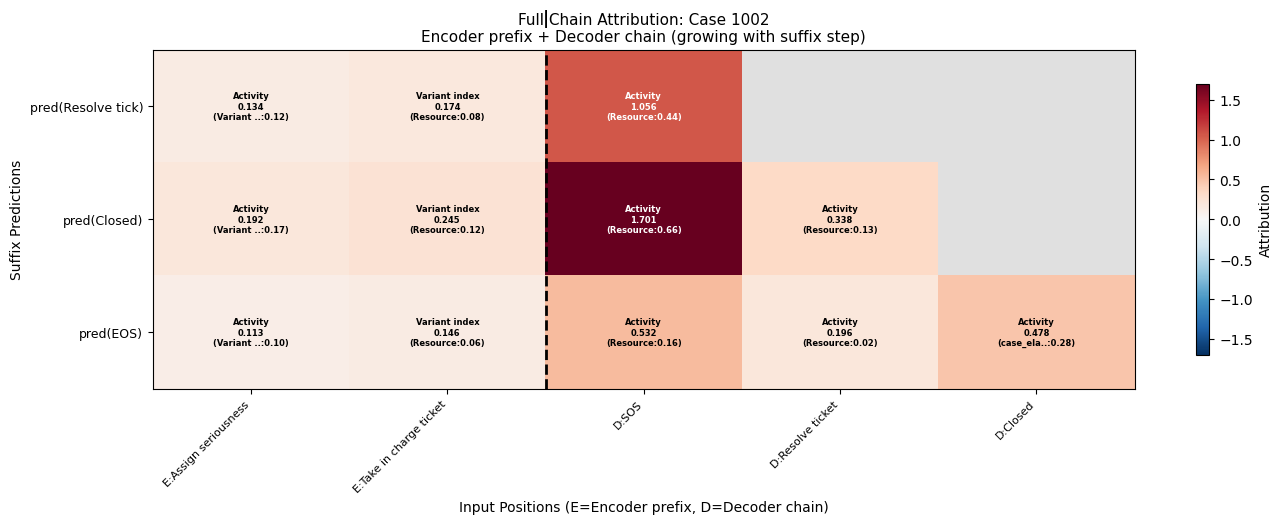

In [8]:
def plot_suffix_heatmap(mag_1st, mag_2nd, feat_1st, feat_2nd, position_labels, suffix_labels, case_name, prefix_len):
    """Plot 2D heatmap showing attributions with encoder/decoder separation.
    
    - Rows: suffix predictions (d, e, f, ...)
    - Columns: input positions (enc(a), enc(b), enc(c), dec(SOS), dec(d), ...)
    - Gray cells: positions that don't exist for that suffix step
    """
    data = mag_1st.T  # [suffix_steps, positions]
    n_suffix, n_positions = data.shape
    
    fig, ax = plt.subplots(figsize=(max(14, n_positions * 2), max(5, n_suffix * 1.8)))
    
    masked_data = np.ma.masked_invalid(data)
    vmax = max(np.nanmax(np.abs(data)), 0.001)
    
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='#e0e0e0')  # Light gray for NaN
    im = ax.imshow(masked_data, cmap=cmap, norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax),
                   aspect='auto', interpolation='nearest')
    
    # Add cell annotations
    for i in range(n_suffix):
        for j in range(n_positions):
            if not np.isnan(data[i, j]):
                feat1 = feat_1st.T[i, j]
                val1 = mag_1st.T[i, j]
                feat2 = feat_2nd.T[i, j]
                val2 = mag_2nd.T[i, j]
                
                color = 'white' if abs(val1) > vmax * 0.5 else 'black'
                text = f"{feat1}\n{val1:.3f}"
                if feat2 is not None and not np.isnan(val2):
                    text += f"\n({feat2[:8]}..:{val2:.2f})" if len(str(feat2)) > 8 else f"\n({feat2}:{val2:.2f})"
                
                ax.text(j, i, text, ha='center', va='center', color=color, fontsize=6, fontweight='bold')
    
    # Draw vertical line between encoder and decoder sections
    ax.axvline(x=prefix_len - 0.5, color='black', linewidth=2, linestyle='--')
    ax.text(prefix_len - 0.5, -0.7, '|', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Labels
    ax.set_xticks(range(n_positions))
    short_labels = [l.replace('enc(', 'E:').replace('dec(', 'D:').replace(')', '') for l in position_labels]
    ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n_suffix))
    ax.set_yticklabels([f"pred({s[:12]})" for s in suffix_labels], fontsize=9)
    
    ax.set_xlabel('Input Positions (E=Encoder prefix, D=Decoder chain)', fontsize=10)
    ax.set_ylabel('Suffix Predictions', fontsize=10)
    ax.set_title(f'Full Chain Attribution: {case_name}\nEncoder prefix + Decoder chain (growing with suffix step)', fontsize=11)
    
    plt.colorbar(im, ax=ax, label='Attribution', shrink=0.8)
    ax.grid(False)
    plt.tight_layout()
    return fig

fig = plot_suffix_heatmap(mag_1st, mag_2nd, feat_1st, feat_2nd, position_labels, suffix_labels, CASE_NAME, PREFIX_LENGTH)
plt.show()

Case-level features (accumulated): ['Variant index', 'customer']
Event-level features (per-position): ['Activity', 'Resource', 'seriousness', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup', 'case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


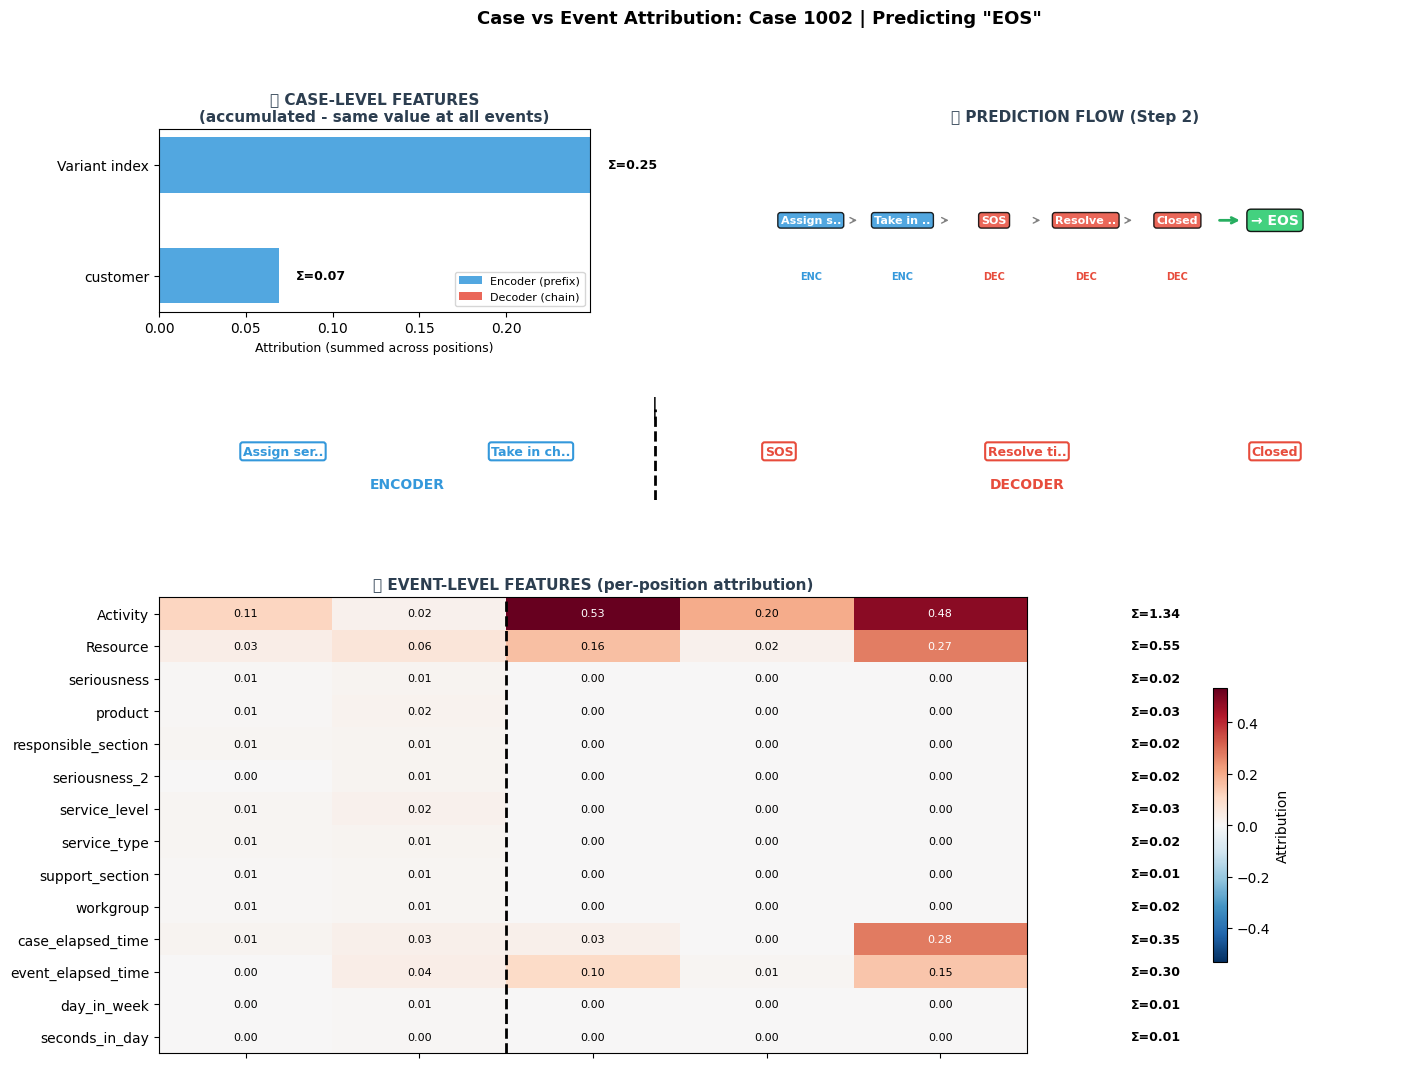

In [9]:
# ============================================================================
# VISUALIZATION: Case-Level vs Event-Level Attribution Split
# ============================================================================
# Case-level features (e.g., Variant index): accumulated across positions
# Event-level features (e.g., Activity): shown per-position with detail

def plot_case_event_split(results, feature_names, prefix_len, case_name, 
                          case_level_features=None, selected_step=None):
    """
    Split visualization: 
    - Case-level features shown as accumulated totals (one bar per feature)
    - Event-level features shown per-position as heatmap rows
    """
    
    # Default case-level features (constant across events in a case)
    if case_level_features is None:
        case_level_features = ['Variant index', 'customer']
    
    event_level_features = [f for f in feature_names if f not in case_level_features]
    
    if selected_step is None:
        selected_step = len(results) - 1
    
    suffix_step, attr_map, pred_desc, step_labels = results[selected_step]
    n_positions = len(step_labels)
    
    pred_label = pred_desc.split('=')[1].split('(')[0].strip() if '=' in pred_desc else f"Step {selected_step}"
    
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, height_ratios=[0.8, 0.4, 2], width_ratios=[1, 1.5], 
                          hspace=0.4, wspace=0.3)
    
    # =========================================================================
    # TOP LEFT: Case-level features (accumulated horizontal bars)
    # =========================================================================
    ax_case = fig.add_subplot(gs[0, 0])
    
    case_totals = {}
    for feat in case_level_features:
        if feat in attr_map.attributions:
            vals = attr_map.attributions[feat]
            vals = vals.detach().cpu().numpy() if hasattr(vals, 'detach') else np.array(vals)
            enc_total = np.sum(vals[:prefix_len])  # Keep sign for direction
            dec_total = np.sum(vals[prefix_len:])
            case_totals[feat] = {'enc': enc_total, 'dec': dec_total}
    
    if case_totals:
        feats = list(case_totals.keys())
        y_pos = np.arange(len(feats))
        
        enc_vals = [case_totals[f]['enc'] for f in feats]
        dec_vals = [case_totals[f]['dec'] for f in feats]
        
        # Stacked bar chart
        bars1 = ax_case.barh(y_pos, enc_vals, height=0.5, label='Encoder (prefix)', 
                             color='#3498db', alpha=0.85)
        bars2 = ax_case.barh(y_pos, dec_vals, height=0.5, left=enc_vals, 
                             label='Decoder (chain)', color='#e74c3c', alpha=0.85)
        
        # Add value labels
        for i, feat in enumerate(feats):
            total = case_totals[feat]['enc'] + case_totals[feat]['dec']
            ax_case.text(total + 0.01, i, f'Σ={total:.2f}', va='center', fontsize=9, fontweight='bold')
        
        ax_case.set_yticks(y_pos)
        ax_case.set_yticklabels(feats, fontsize=10)
        ax_case.axvline(x=0, color='gray', linewidth=0.5, linestyle='-')
        ax_case.set_xlabel('Attribution (summed across positions)', fontsize=9)
        ax_case.set_title('📊 CASE-LEVEL FEATURES\n(accumulated - same value at all events)', 
                         fontsize=11, fontweight='bold', color='#2c3e50')
        ax_case.legend(loc='lower right', fontsize=8)
        ax_case.invert_yaxis()
    
    # =========================================================================
    # TOP RIGHT: Sequence flow diagram
    # =========================================================================
    ax_seq = fig.add_subplot(gs[0, 1])
    
    x = 0.02
    box_width = 0.85 / (n_positions + 1)
    
    for i, label in enumerate(step_labels):
        short_label = label.replace('enc(', '').replace('dec(', '').replace(')', '')
        if len(short_label) > 10:
            short_label = short_label[:8] + '..'
        
        is_enc = i < prefix_len
        color = '#3498db' if is_enc else '#e74c3c'
        
        bbox = dict(boxstyle='round,pad=0.25', facecolor=color, alpha=0.85)
        ax_seq.text(x + box_width/2, 0.5, short_label, ha='center', va='center',
                   fontsize=8, fontweight='bold', color='white', bbox=bbox)
        ax_seq.text(x + box_width/2, 0.18, 'ENC' if is_enc else 'DEC', 
                   ha='center', fontsize=7, color=color, fontweight='bold')
        
        if i < n_positions - 1:
            ax_seq.annotate('', xy=(x + box_width + 0.005, 0.5), xytext=(x + box_width - 0.01, 0.5),
                           arrowprops=dict(arrowstyle='->', color='gray', lw=1))
        x += box_width
    
    # Final prediction
    ax_seq.annotate('', xy=(x + 0.03, 0.5), xytext=(x - 0.01, 0.5),
                   arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))
    bbox = dict(boxstyle='round,pad=0.3', facecolor='#2ecc71', alpha=0.9)
    ax_seq.text(x + 0.08, 0.5, f'→ {pred_label[:15]}', ha='center', va='center',
               fontsize=10, fontweight='bold', color='white', bbox=bbox)
    
    ax_seq.set_xlim(0, 1)
    ax_seq.set_ylim(0, 1)
    ax_seq.axis('off')
    ax_seq.set_title(f'🔄 PREDICTION FLOW (Step {selected_step})', fontsize=11, fontweight='bold', color='#2c3e50')
    
    # =========================================================================
    # MIDDLE: Position labels spanning full width
    # =========================================================================
    ax_labels = fig.add_subplot(gs[1, :])
    ax_labels.set_xlim(0, n_positions)
    
    for i, label in enumerate(step_labels):
        short_label = label.replace('enc(', '').replace('dec(', '').replace(')', '')
        if len(short_label) > 12:
            short_label = short_label[:10] + '..'
        
        is_enc = i < prefix_len
        color = '#3498db' if is_enc else '#e74c3c'
        
        ax_labels.text(i + 0.5, 0.5, short_label, ha='center', va='center',
                      fontsize=9, fontweight='bold', color=color,
                      bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                               edgecolor=color, linewidth=1.5))
    
    # Separator line
    ax_labels.axvline(x=prefix_len, color='black', linewidth=2, linestyle='--')
    ax_labels.text(prefix_len, 1.05, '│', ha='center', va='bottom', fontsize=14, fontweight='bold')
    ax_labels.text(prefix_len/2, -0.1, 'ENCODER', ha='center', fontsize=10, color='#3498db', fontweight='bold')
    ax_labels.text(prefix_len + (n_positions-prefix_len)/2, -0.1, 'DECODER', ha='center', fontsize=10, color='#e74c3c', fontweight='bold')
    
    ax_labels.set_ylim(-0.3, 1.2)
    ax_labels.axis('off')
    
    # =========================================================================
    # BOTTOM: Event-level features heatmap (per-position)
    # =========================================================================
    ax_event = fig.add_subplot(gs[2, :])
    
    event_matrix = np.zeros((len(event_level_features), n_positions))
    for i, feat in enumerate(event_level_features):
        if feat in attr_map.attributions:
            vals = attr_map.attributions[feat]
            vals = vals.detach().cpu().numpy() if hasattr(vals, 'detach') else np.array(vals)
            event_matrix[i, :min(len(vals), n_positions)] = vals[:n_positions]
    
    vmax = np.max(np.abs(event_matrix)) if np.max(np.abs(event_matrix)) > 0 else 1
    
    im = ax_event.imshow(event_matrix, cmap='RdBu_r', aspect='auto',
                         norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax))
    
    # Add values
    for i in range(len(event_level_features)):
        for j in range(n_positions):
            val = event_matrix[i, j]
            color = 'white' if abs(val) > vmax * 0.4 else 'black'
            ax_event.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)
    
    # Row totals on the right
    for i, feat in enumerate(event_level_features):
        row_total = np.sum(event_matrix[i, :])
        ax_event.text(n_positions + 0.1, i, f'Σ={row_total:.2f}', va='center', fontsize=9, fontweight='bold')
    
    ax_event.set_xticks(range(n_positions))
    ax_event.set_xticklabels([])  # Labels shown in middle section
    ax_event.set_yticks(range(len(event_level_features)))
    ax_event.set_yticklabels(event_level_features, fontsize=10)
    ax_event.axvline(x=prefix_len - 0.5, color='black', linewidth=2, linestyle='--')
    
    ax_event.set_title('📈 EVENT-LEVEL FEATURES (per-position attribution)', 
                      fontsize=11, fontweight='bold', color='#2c3e50')
    
    plt.colorbar(im, ax=ax_event, shrink=0.6, label='Attribution', pad=0.15)
    
    fig.suptitle(f'Case vs Event Attribution: {case_name} | Predicting "{pred_label}"', 
                fontsize=13, fontweight='bold', y=0.98)
    
    return fig

# Define case-level vs event-level features for this dataset
CASE_LEVEL_FEATURES = ['Variant index', 'customer']
print(f"Case-level features (accumulated): {CASE_LEVEL_FEATURES}")
print(f"Event-level features (per-position): {[f for f in feature_names if f not in CASE_LEVEL_FEATURES]}")

# Show for the last prediction (most decoder inputs)
fig_split = plot_case_event_split(results, feature_names, PREFIX_LENGTH, CASE_NAME,
                                   case_level_features=CASE_LEVEL_FEATURES,
                                   selected_step=len(results)-1)
plt.show()

Case-level features: ['Variant index', 'customer']
Event-level features: ['Activity', 'Resource', 'seriousness', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup', 'case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']


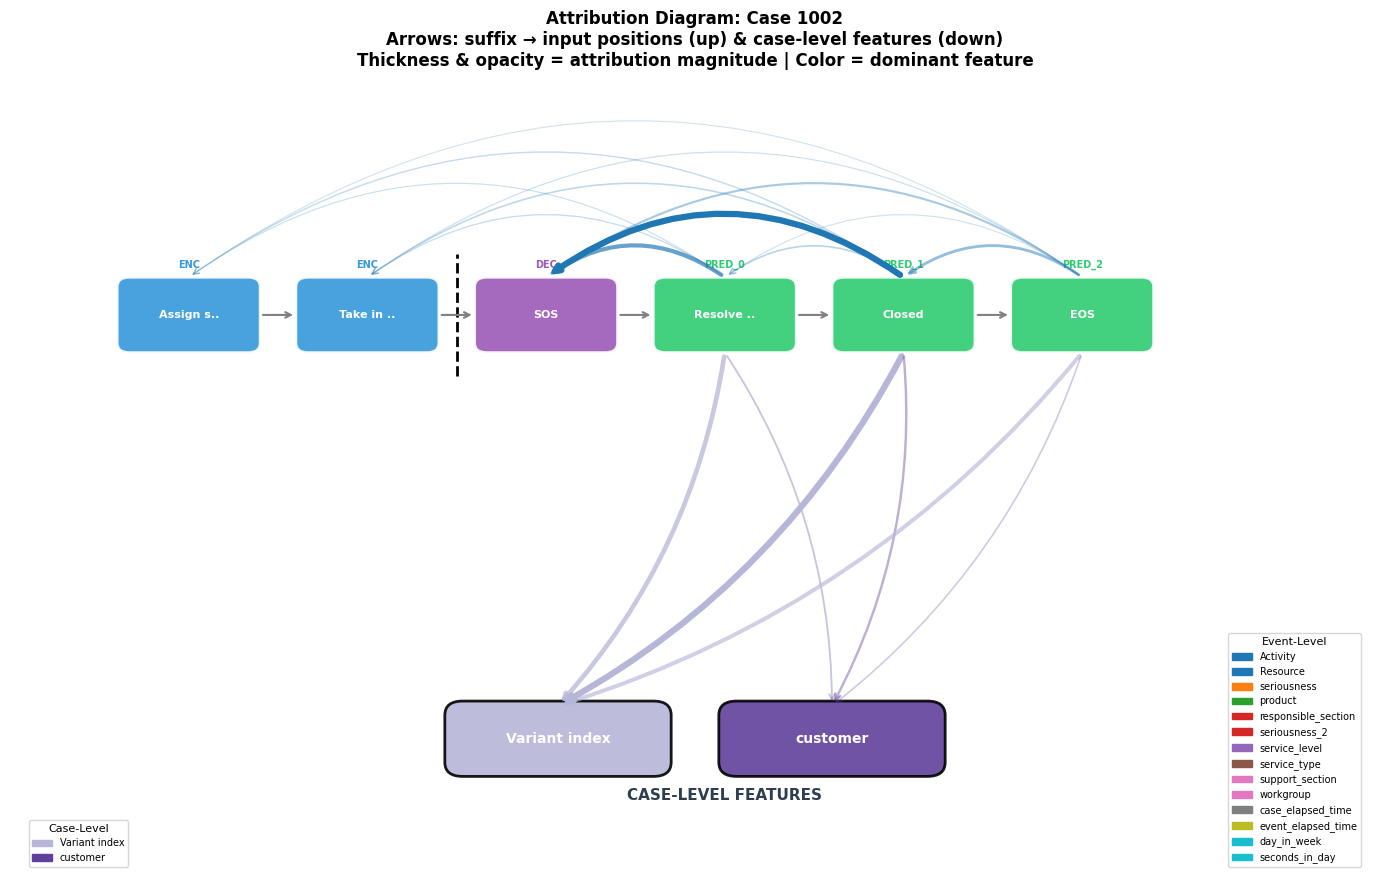

In [10]:
# ============================================================================
# CASE-LEVEL & EVENT-LEVEL ATTRIBUTION VISUALIZATION
# ============================================================================
# Layout (top to bottom):
#   1. Unified sequence: encoder prefix + dec(SOS) + suffix predictions
#   2. Case-level feature boxes underneath
#
# Attribution arrows:
#   - Upward from suffix predictions to earlier input positions
#   - Downward from suffix predictions to case-level features

import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

def plot_attribution_diagram(results, feature_names, prefix_len, case_name,
                              case_level_features=None):
    """
    Attribution visualization with case-level and event-level separation.
    
    Layout:
        - Top: Unified sequence (encoder prefix + SOS + suffix predictions)
        - Bottom: Case-level feature boxes
    
    Arrows:
        - From suffix predictions up to earlier positions (encoder + SOS + earlier preds)
        - From suffix predictions down to case-level features
    """
    
    if case_level_features is None:
        case_level_features = ['Variant index', 'customer']
    
    event_level_features = [f for f in feature_names if f not in case_level_features]
    
    n_suffix = len(results)
    
    # Get labels from results
    _, _, _, first_step_labels = results[0]
    encoder_labels = first_step_labels[:prefix_len]
    
    # Suffix prediction labels
    suffix_labels = []
    for s_idx, (_, _, pred_desc, _) in enumerate(results):
        pred_label = pred_desc.split('=')[1].split('(')[0].strip() if '=' in pred_desc else f"pred_{s_idx}"
        suffix_labels.append(pred_label)
    
    # Total sequence length
    n_encoder = prefix_len
    n_sequence = n_encoder + 1 + n_suffix
    
    # Color palettes
    case_colors = plt.cm.Purples(np.linspace(0.4, 0.8, len(case_level_features)))
    case_feature_colors = {f: case_colors[i] for i, f in enumerate(case_level_features)}
    
    event_colors = plt.cm.tab10(np.linspace(0, 1, len(event_level_features)))
    event_feature_colors = {f: event_colors[i] for i, f in enumerate(event_level_features)}
    
    # Figure setup
    fig_width = max(14, n_sequence * 1.8 + 2)
    fig_height = 9
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    # Layout coordinates - sequence on top, case-level below
    seq_y = 6.5           # Unified sequence (moved up)
    case_y = 2.0          # Case-level feature boxes (now below)
    
    x_start = 1.0
    box_spacing = 1.5
    
    ax.set_xlim(-0.5, n_sequence * box_spacing + 2)
    ax.set_ylim(0.5, 9)
    ax.axis('off')
    
    # =========================================================================
    # 1. UNIFIED SEQUENCE (encoder + SOS + suffix predictions) - TOP
    # =========================================================================
    box_positions = []  # (x, y_top, y_bottom, box_type)
    box_width = 1.1
    box_height = 0.7
    
    seq_idx = 0
    
    # --- Encoder positions ---
    for i, label in enumerate(encoder_labels):
        sx = x_start + seq_idx * box_spacing
        
        short_label = label.replace('enc(', '').replace(')', '')
        if len(short_label) > 10:
            short_label = short_label[:8] + '..'
        
        box = FancyBboxPatch((sx - box_width/2, seq_y - box_height/2),
                             box_width, box_height,
                             boxstyle="round,pad=0.05,rounding_size=0.1",
                             facecolor='#3498db', edgecolor='white', linewidth=2, alpha=0.9)
        ax.add_patch(box)
        
        ax.text(sx, seq_y, short_label, ha='center', va='center',
               fontsize=8, fontweight='bold', color='white')
        ax.text(sx, seq_y + box_height/2 + 0.15, 'ENC', ha='center',
               fontsize=7, color='#3498db', fontweight='bold')
        
        box_positions.append((sx, seq_y + box_height/2, seq_y - box_height/2, 'encoder'))
        seq_idx += 1
    
    # --- dec(SOS) ---
    sx = x_start + seq_idx * box_spacing
    short_label = "SOS"
    
    box = FancyBboxPatch((sx - box_width/2, seq_y - box_height/2),
                         box_width, box_height,
                         boxstyle="round,pad=0.05,rounding_size=0.1",
                         facecolor='#9b59b6', edgecolor='white', linewidth=2, alpha=0.9)
    ax.add_patch(box)
    
    ax.text(sx, seq_y, short_label, ha='center', va='center',
           fontsize=8, fontweight='bold', color='white')
    ax.text(sx, seq_y + box_height/2 + 0.15, 'DEC', ha='center',
           fontsize=7, color='#9b59b6', fontweight='bold')
    
    box_positions.append((sx, seq_y + box_height/2, seq_y - box_height/2, 'sos'))
    seq_idx += 1
    
    # --- Suffix predictions ---
    suffix_box_indices = []
    
    for s_idx, pred_label in enumerate(suffix_labels):
        sx = x_start + seq_idx * box_spacing
        
        short_label = pred_label if len(pred_label) <= 10 else pred_label[:8] + '..'
        
        box = FancyBboxPatch((sx - box_width/2, seq_y - box_height/2),
                             box_width, box_height,
                             boxstyle="round,pad=0.05,rounding_size=0.1",
                             facecolor='#2ecc71', edgecolor='white', linewidth=2, alpha=0.9)
        ax.add_patch(box)
        
        ax.text(sx, seq_y, short_label, ha='center', va='center',
               fontsize=8, fontweight='bold', color='white')
        ax.text(sx, seq_y + box_height/2 + 0.15, f'PRED_{s_idx}', ha='center',
               fontsize=7, color='#2ecc71', fontweight='bold')
        
        suffix_box_indices.append(len(box_positions))
        box_positions.append((sx, seq_y + box_height/2, seq_y - box_height/2, 'suffix'))
        seq_idx += 1
    
    # =========================================================================
    # 2. SEQUENCE FLOW ARROWS (between boxes)
    # =========================================================================
    for i in range(len(box_positions) - 1):
        x1, _, y1_bottom, _ = box_positions[i]
        x2, _, y2_bottom, _ = box_positions[i + 1]
        
        ax.annotate('',
                   xy=(x2 - box_width/2 - 0.05, seq_y),
                   xytext=(x1 + box_width/2 + 0.05, seq_y),
                   arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    
    # Encoder/Decoder separator line
    sep_x = x_start + (prefix_len - 0.5) * box_spacing
    ax.plot([sep_x, sep_x], [seq_y - box_height/2 - 0.3, seq_y + box_height/2 + 0.3], 
           color='black', linewidth=2, linestyle='--')
    
    # =========================================================================
    # 3. CASE-LEVEL FEATURE BOXES (bottom)
    # =========================================================================
    n_case = len(case_level_features)
    case_box_width = 1.8
    case_box_height = 0.7
    case_total_width = n_case * (case_box_width + 0.5)
    case_start_x = (n_sequence * box_spacing) / 2 - case_total_width / 2 + x_start
    
    case_box_positions = {}
    for i, feat in enumerate(case_level_features):
        cx = case_start_x + i * (case_box_width + 0.5) + case_box_width / 2
        
        color = case_feature_colors[feat]
        box = FancyBboxPatch((cx - case_box_width/2, case_y - case_box_height/2),
                             case_box_width, case_box_height,
                             boxstyle="round,pad=0.05,rounding_size=0.15",
                             facecolor=color, edgecolor='black', linewidth=2, alpha=0.9)
        ax.add_patch(box)
        
        feat_label = feat if len(feat) <= 14 else feat[:12] + '..'
        ax.text(cx, case_y, feat_label, ha='center', va='center',
               fontsize=10, fontweight='bold', color='white')
        
        case_box_positions[feat] = (cx, case_y + case_box_height/2)  # Store top of box for arrows
    
    ax.text((n_sequence * box_spacing) / 2 + x_start, case_y - case_box_height/2 - 0.3,
           'CASE-LEVEL FEATURES', ha='center', fontsize=11, fontweight='bold', color='#2c3e50')
    
    # =========================================================================
    # COMPUTE GLOBAL MAX FOR ARROW SCALING
    # =========================================================================
    global_max_event = 0.001
    global_max_case = 0.001
    
    for s_idx, (suffix_step, attr_map, pred_desc, step_labels) in enumerate(results):
        n_pos = len(step_labels)
        
        for p in range(n_pos):
            event_sum = sum(abs(attr_map.attributions[f][p].item() 
                               if hasattr(attr_map.attributions[f][p], 'item') 
                               else abs(attr_map.attributions[f][p]))
                          for f in event_level_features
                          if f in attr_map.attributions and p < len(attr_map.attributions[f]))
            global_max_event = max(global_max_event, event_sum)
        
        for feat in case_level_features:
            if feat in attr_map.attributions:
                vals = attr_map.attributions[feat]
                vals = vals.detach().cpu().numpy() if hasattr(vals, 'detach') else np.array(vals)
                case_total = np.sum(np.abs(vals[:n_pos]))
                global_max_case = max(global_max_case, case_total)
    
    # =========================================================================
    # DRAW ATTRIBUTION ARROWS: Suffix → earlier positions (event-level) - UPWARD
    # =========================================================================
    for s_idx, (suffix_step, attr_map, pred_desc, step_labels) in enumerate(results):
        n_input_pos = len(step_labels)
        
        suffix_box_idx = suffix_box_indices[s_idx]
        sx, sy_top, sy_bottom, _ = box_positions[suffix_box_idx]
        
        for p in range(n_input_pos):
            event_sum = 0
            max_event_val = 0
            max_event_feat = None
            
            for feat in event_level_features:
                if feat in attr_map.attributions and p < len(attr_map.attributions[feat]):
                    val = attr_map.attributions[feat][p]
                    val = val.item() if hasattr(val, 'item') else val
                    event_sum += abs(val)
                    if abs(val) > max_event_val:
                        max_event_val = abs(val)
                        max_event_feat = feat
            
            if event_sum < global_max_event * 0.02 or max_event_feat is None:
                continue
            
            # Width and opacity scaling
            ratio = event_sum / global_max_event
            width = 0.5 + 4 * ratio
            alpha = 0.15 + 0.85 * ratio  # More aggressive opacity: 0.15 to 1.0
            color = event_feature_colors.get(max_event_feat, 'gray')
            
            target_box_idx = p
            tx, ty_top, ty_bottom, _ = box_positions[target_box_idx]
            
            # Draw curved arrow upward
            ax.annotate('',
                       xy=(tx, ty_top + 0.05),
                       xytext=(sx, sy_top + 0.05),
                       arrowprops=dict(arrowstyle='->', color=color, lw=width,
                                      alpha=alpha, connectionstyle="arc3,rad=0.35",
                                      shrinkA=3, shrinkB=3))
    
    # =========================================================================
    # DRAW ATTRIBUTION ARROWS: Suffix → Case-level features - DOWNWARD
    # =========================================================================
    for s_idx, (suffix_step, attr_map, pred_desc, step_labels) in enumerate(results):
        n_pos = len(step_labels)
        
        suffix_box_idx = suffix_box_indices[s_idx]
        sx, sy_top, sy_bottom, _ = box_positions[suffix_box_idx]
        
        for feat in case_level_features:
            if feat not in attr_map.attributions:
                continue
            
            vals = attr_map.attributions[feat]
            vals = vals.detach().cpu().numpy() if hasattr(vals, 'detach') else np.array(vals)
            case_total = np.sum(np.abs(vals[:n_pos]))
            
            if case_total < global_max_case * 0.02:
                continue
            
            # Width and opacity scaling
            ratio = case_total / global_max_case
            width = 0.5 + 4 * ratio
            alpha = 0.15 + 0.85 * ratio  # More aggressive opacity: 0.15 to 1.0
            color = case_feature_colors[feat]
            
            cx, cy_top = case_box_positions[feat]
            
            # Draw arrow downward from suffix to case-level feature
            ax.annotate('',
                       xy=(cx, cy_top),
                       xytext=(sx, sy_bottom - 0.05),
                       arrowprops=dict(arrowstyle='->', color=color, lw=width,
                                      alpha=alpha, connectionstyle="arc3,rad=-0.15",
                                      shrinkA=3, shrinkB=3))
    
    # =========================================================================
    # LEGEND
    # =========================================================================
    case_patches = [mpatches.Patch(color=case_feature_colors[f], label=f) 
                   for f in case_level_features]
    event_patches = [mpatches.Patch(color=event_feature_colors[f], label=f) 
                    for f in event_level_features]
    
    legend1 = ax.legend(handles=case_patches, loc='lower left', title='Case-Level',
                       fontsize=7, title_fontsize=8, bbox_to_anchor=(0.01, 0.01))
    ax.add_artist(legend1)
    ax.legend(handles=event_patches, loc='lower right', title='Event-Level',
             fontsize=7, title_fontsize=8, bbox_to_anchor=(0.99, 0.01))
    
    # Title
    ax.set_title(f'Attribution Diagram: {case_name}\n'
                f'Arrows: suffix → input positions (up) & case-level features (down)\n'
                f'Thickness & opacity = attribution magnitude | Color = dominant feature',
                fontsize=12, fontweight='bold', pad=10)
    
    plt.tight_layout()
    return fig

# Define feature classification
CASE_LEVEL_FEATURES = ['Variant index', 'customer']
EVENT_LEVEL_FEATURES = [f for f in feature_names if f not in CASE_LEVEL_FEATURES]

print(f"Case-level features: {CASE_LEVEL_FEATURES}")
print(f"Event-level features: {EVENT_LEVEL_FEATURES}")

# Run visualization
fig_diagram = plot_attribution_diagram(
    results, feature_names, PREFIX_LENGTH, CASE_NAME,
    case_level_features=CASE_LEVEL_FEATURES
)
plt.show()

In [11]:
# ============================================================================
# ATTRIBUTION SUMMARY TABLE
# ============================================================================
# Summary of total attributions per suffix step

def print_attribution_summary(results, feature_names, case_level_features=None):
    """Print summary table of attributions."""
    
    if case_level_features is None:
        case_level_features = ['Variant index', 'customer']
    
    event_level_features = [f for f in feature_names if f not in case_level_features]
    
    print("=" * 80)
    print("ATTRIBUTION SUMMARY")
    print("=" * 80)
    
    for s_idx, (suffix_step, attr_map, pred_desc, step_labels) in enumerate(results):
        n_pos = len(step_labels)
        pred_label = pred_desc.split('=')[1].split('(')[0].strip() if '=' in pred_desc else f"Step {s_idx}"
        
        print(f"\n--- Suffix Step {s_idx}: {pred_label} ---")
        print(f"    Input positions: {n_pos} ({step_labels})")
        
        # Case-level totals
        print(f"\n    Case-level feature totals:")
        for feat in case_level_features:
            if feat in attr_map.attributions:
                vals = attr_map.attributions[feat]
                vals = vals.detach().cpu().numpy() if hasattr(vals, 'detach') else np.array(vals)
                total = np.sum(np.abs(vals[:n_pos]))
                print(f"      {feat}: {total:.4f}")
        
        # Event-level per-position
        print(f"\n    Event-level attribution by position:")
        for p in range(n_pos):
            event_sum = 0
            max_feat = None
            max_val = 0
            for feat in event_level_features:
                if feat in attr_map.attributions and p < len(attr_map.attributions[feat]):
                    val = attr_map.attributions[feat][p]
                    val = val.item() if hasattr(val, 'item') else val
                    event_sum += abs(val)
                    if abs(val) > max_val:
                        max_val = abs(val)
                        max_feat = feat
            
            pos_label = step_labels[p] if p < len(step_labels) else f"pos_{p}"
            print(f"      {pos_label}: Σ={event_sum:.4f} (dominant: {max_feat})")
    
    print("\n" + "=" * 80)

# Print summary
print_attribution_summary(results, feature_names, CASE_LEVEL_FEATURES)

ATTRIBUTION SUMMARY

--- Suffix Step 0: Resolve ticket ---
    Input positions: 3 (['enc(Assign seriousness)', 'enc(Take in charge ticket)', 'dec(SOS)'])

    Case-level feature totals:
      Variant index: 0.2963
      customer: 0.0852

    Event-level attribution by position:
      enc(Assign seriousness): Σ=0.2720 (dominant: Activity)
      enc(Take in charge ticket): Σ=0.3443 (dominant: Resource)
      dec(SOS): Σ=1.8977 (dominant: Activity)

--- Suffix Step 1: Closed ---
    Input positions: 4 (['enc(Assign seriousness)', 'enc(Take in charge ticket)', 'dec(SOS)', 'dec(Resolve ticket)'])

    Case-level feature totals:
      Variant index: 0.4193
      customer: 0.1316

    Event-level attribution by position:
      enc(Assign seriousness): Σ=0.3947 (dominant: Activity)
      enc(Take in charge ticket): Σ=0.5047 (dominant: Resource)
      dec(SOS): Σ=3.0298 (dominant: Activity)
      dec(Resolve ticket): Σ=0.5471 (dominant: Activity)

--- Suffix Step 2: EOS ---
    Input positions: